1.0000000000000002
100.0


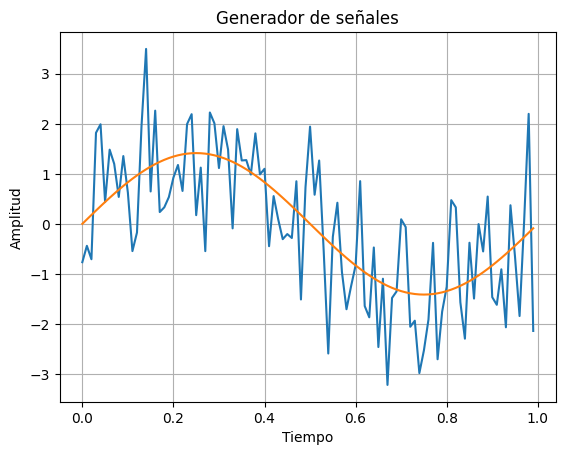

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def  mi_funcion_sen(vmax, dc, ff,ph, nn, fs):

 
  
    xx=dc +vmax*np.sin(2*np.pi*ff*tt+ ph)
    return tt,xx
N=100
fs=100
ts=1/fs
tt = np.arange(N) * ts
sigma=1
u=0
SNR=-20
t1,x1= mi_funcion_sen(vmax= np.sqrt(2), dc = 0, ff = 1, ph=0, nn = N, fs = fs)
#t2,x2= mi_funcion_sen(vmax= 1, dc = 0, ff = 35, ph=0, nn = N, fs = fs)
#t3,x3= mi_funcion_sen(vmax= 1, dc = 0, ff = 65, ph=0, nn = N, fs = fs)
#ff=fs/2 es nyquist
#filtro
rn=np.random.normal(u,sigma,N)
xs=x1+rn
#snr de la señal

#loc=centro de distribucion
#scale=sigma sin el cuadrado
#size=tamaño que quiero que me devuelva el vector

plt.plot(tt,xs)
plt.plot(t1,x1 )
#plt.plot(t2,x2)
#plt.plot(t3,x3)

plt.title("Generador de señales")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)

var=np.var(x1)
print(var)
#SNR=10*np.log(1/POT)
pot=10**-(SNR/10)
print(pot)

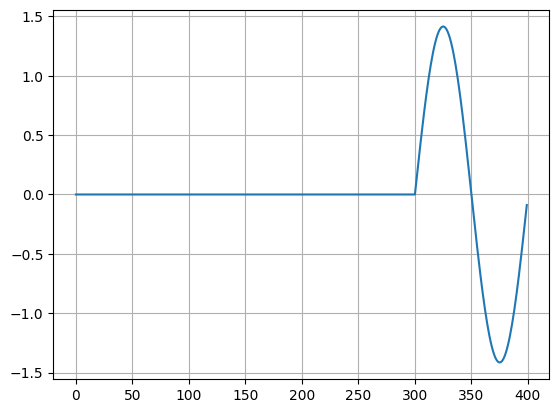

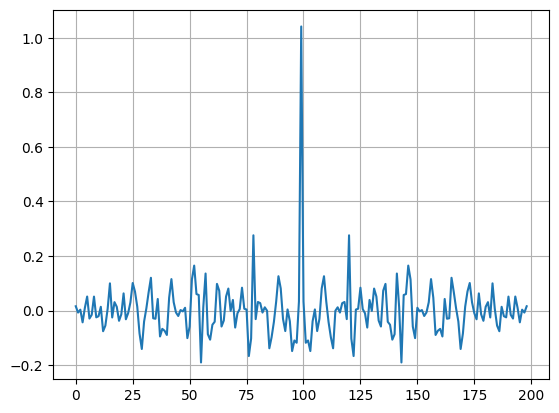

In [2]:
from scipy import signal as sig
n0= 300
dd=np.zeros(n0+1)
dd[n0]=1.
yy = sig.convolve(x1, dd)
plt.figure(2)
plt.clf()
plt.plot(yy)
plt.grid(True)
#%%
yy=1/N*sig.convolve(rn, np.flip(rn))
plt.figure(3)
plt.clf()
plt.plot(yy)
plt.grid(True)

[ 0.00000000e+00  8.87992043e-02 -1.02520413e-02  7.74971964e-02
 -2.32993887e-02  6.20160244e-02 -4.18932650e-02  3.96428487e-02
 -6.86974204e-02  7.77352054e-03  8.12538756e-02 -3.60463487e-02
  3.05958013e-02  9.34173194e-02 -3.53297221e-02  1.91228056e-02
  6.90600033e-02 -7.32152083e-02 -3.28813108e-02  2.40251632e-03
  3.24970239e-02  5.72834428e-02  7.66639521e-02  9.05620660e-02
 -8.85770650e-02 -8.57864376e-02 -8.85770650e-02  9.05620660e-02
  7.66639521e-02  5.72834428e-02  3.24970239e-02  2.40251632e-03
 -3.28813108e-02 -7.32152083e-02  6.90600033e-02  1.91228056e-02
 -3.53297221e-02  9.34173194e-02  3.05958013e-02 -3.60463487e-02
  8.12538756e-02  7.77352054e-03 -6.86974204e-02  3.96428487e-02
 -4.18932650e-02  6.20160244e-02 -2.32993887e-02  7.74971964e-02
 -1.02520413e-02  8.87992043e-02  1.73191211e-16 -8.87992043e-02
  1.02520413e-02 -7.74971964e-02  2.32993887e-02 -6.20160244e-02
  4.18932650e-02 -3.96428487e-02  6.86974204e-02 -7.77352054e-03
 -8.12538756e-02  3.60463

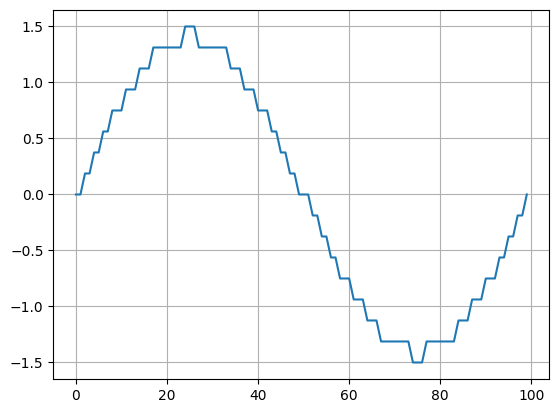

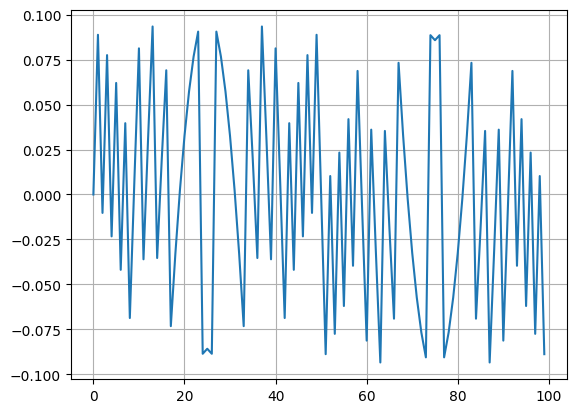

In [3]:
#Cuantizacion
B= 4 #bits
Vfs=3 #volts

qq = Vfs/2**B

xxq=np.round(x1/qq)*qq

#bonus=Calcular secuencia de error, graficar histograma y verificar distribución.
ee=x1-xxq
print(ee)
#tiene sentido el error ya que esta entre -qq/2 y qq/2
plt.figure(4)
plt.clf()
plt.plot(xxq)
plt.grid(True)
plt.figure(5)
plt.clf()
plt.plot(ee)
plt.grid(True)